# Data parsing and exploration for learnedcache

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import numpy as np
import csv
import glob
from pathlib import Path

In [2]:
def parse_log_to_csv(input_filepath, output_filepath):
    """
    Parses a log file line-by-line and writes directly to a CSV 
    """
    with open(input_filepath, 'r') as infile:
        first_line = infile.readline()
        if not first_line:
            print("The file is empty.")
            return

        def parse_line(line):
            return dict(item.split('=') for item in line.strip().split() if '=' in item)

        initial_data = parse_line(first_line)
        fieldnames = list(initial_data.keys())

        with open(output_filepath, 'w', newline='') as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
            writer.writeheader()
            
            writer.writerow(initial_data)

            for line in infile:
                if line.strip():
                    row_data = parse_line(line)
                    writer.writerow(row_data)

def transform_logs_to_csvs(input_pattern):
    """
    Parses multiple log files matching the input pattern and writes each to a corresponding CSV file.
    """
    filepaths = glob.glob(input_pattern)
    for filepath in filepaths:
        parse_log_to_csv(filepath, Path(filepath).with_suffix('.csv'))

In [3]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    """
    Reads multiple CSV files and concatenates them into a single dataframe.
    Adds a trial_id column based on the sequence in which files are loaded.
    """
    filepaths = glob.glob(file_pattern)
    dataframes = []
    for trial_id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df['trial_id'] = trial_id
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    return combined_df


In [5]:
transform_logs_to_csvs('data/fileserver/*.log')

In [4]:
df = read_csvs_to_dataframe('data/fileserver/*access.csv')

In [7]:
df.head()

,t,d,i,o,s,z,f,trial_id
0,0,253:0,3933227,0,0,35328,1000,0
1,0,253:0,3933227,1,1,35328,1000,0
2,0,253:0,3933227,2,1,35328,1000,0
3,0,253:0,3933227,3,1,35328,1000,0
4,0,253:0,3933227,4,1,35328,1000,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21136516 entries, 0 to 21136515
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   t         int64 
 1   d         object
 2   i         int64 
 3   o         int64 
 4   s         int64 
 5   z         int64 
 6   f         int64 
 7   trial_id  int64 
dtypes: int64(7), object(1)
memory usage: 1.3+ GB


In [9]:
pd.set_option('display.precision', 5)
df.describe()

,t,i,o,s,z,f,trial_id
count,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07,2.11365e+07
mean,2.38889e+09,1.26616e+08,1.87051e+06,5.47916e-01,3.21737e+10,2.17830e+06,3.54565e+00
std,6.07509e+09,1.32076e+08,2.28498e+06,4.97699e-01,3.37802e+10,2.07882e+07,2.31576e+00
min,0.00000e+00,1.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,1.00000e+03,0.00000e+00
25%,2.29230e+04,9.21258e+05,2.00000e+01,0.00000e+00,1.56332e+05,1.03100e+03,2.00000e+00
50%,1.29360e+07,9.25723e+05,6.62000e+02,1.00000e+00,4.81240e+05,4.00200e+03,4.00000e+00
75%,1.45910e+09,2.65290e+08,3.67029e+06,1.00000e+00,6.76415e+10,1.50156e+05,6.00000e+00
max,7.84853e+10,2.65290e+08,1.59599e+07,1.00000e+00,6.76415e+10,4.16784e+08,7.00000e+00


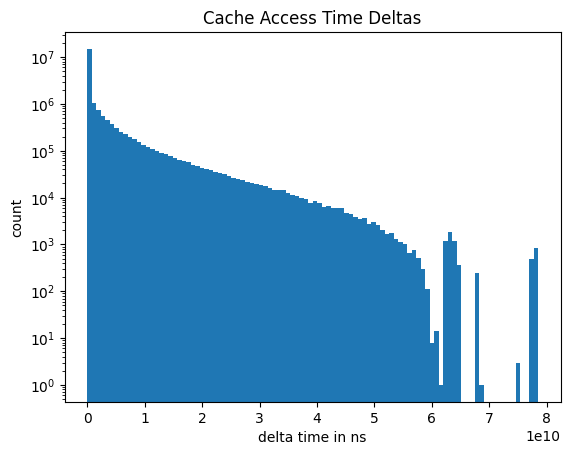

In [10]:
df['t'].plot(title='Cache Access Time Deltas', ylabel='count', xlabel="delta time in ns", kind='hist', bins=100)
plt.yscale('log')
plt.show()

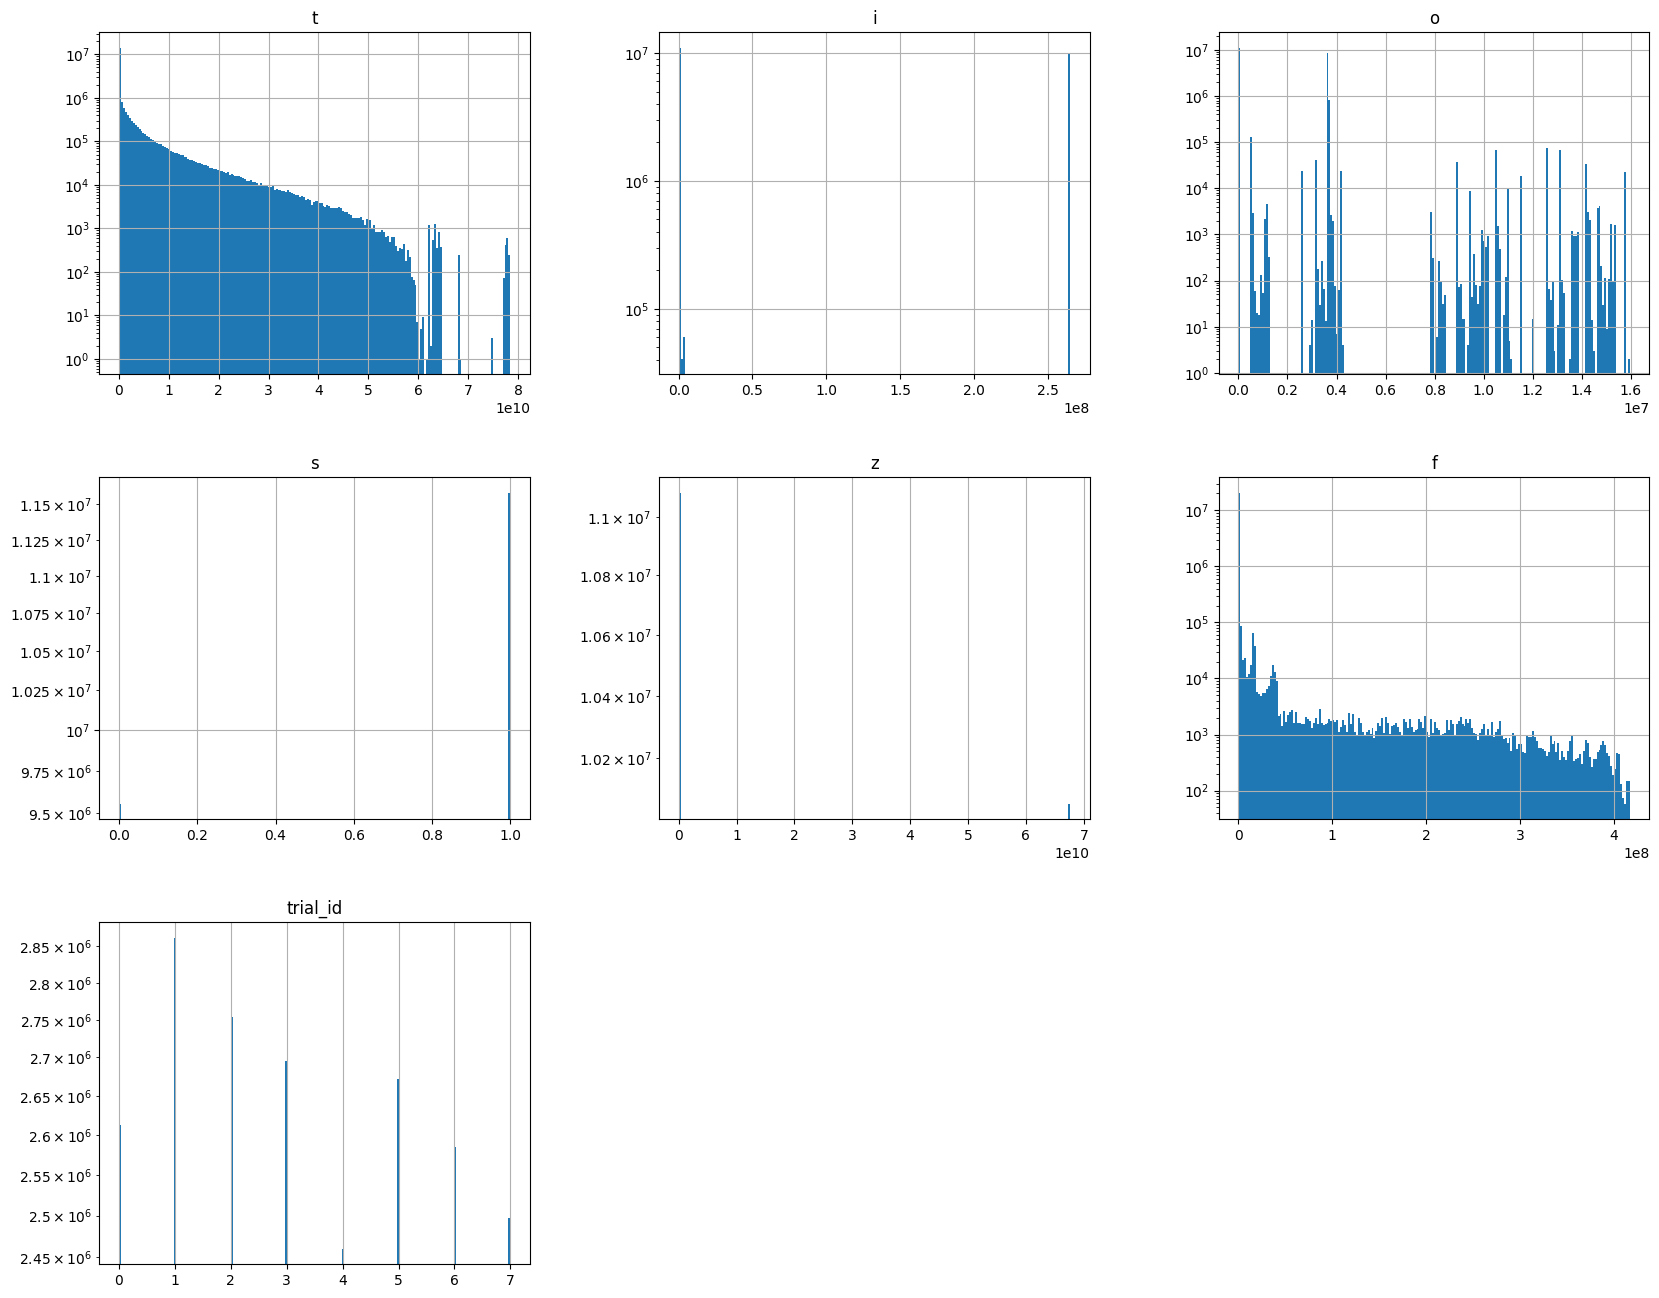

In [16]:
df.hist(figsize=(20,16), bins=200, log=True)
plt.show()

In [5]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = 'ordinal',
    strategy: str = 'quantile',
    subsample: int | None = None,
    random_state: int | None = None
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    """
    Train a KBinsDiscretizer on the training dataset and return the transformed dataframe.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training dataset to fit and transform
    n_bins : int, default=5
        Number of bins to produce. Must be >= 2.
    encode : {'onehot', 'onehot-dense', 'ordinal'}, default='ordinal'
        Method used to encode the transformed result.
        - 'onehot': Encode the transformed result with one-hot encoding
        - 'onehot-dense': Same as 'onehot' but returns dense array
        - 'ordinal': Return the bin identifier encoded as an integer value
    strategy : {'uniform', 'quantile', 'kmeans'}, default='quantile'
        Strategy used to define the widths of the bins.
        - 'uniform': All bins have identical widths
        - 'quantile': All bins have the same number of points
        - 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster
    subsample : int or None, default=None
        Maximum number of samples used to fit the model. If None, all samples are used.
    random_state : int or None, default=None
        Random state for reproducibility when using 'kmeans' strategy.
    
    Returns
    -------
    tuple[pd.DataFrame, KBinsDiscretizer]
        A tuple containing:
        - Transformed dataframe with discretized values
        - Fitted KBinsDiscretizer object for future transformations
    
    Examples
    --------
    >>> import pandas as pd
    >>> X_train = pd.DataFrame({'feature1': [1, 2, 3, 4, 5], 'feature2': [10, 20, 30, 40, 50]})
    >>> X_transformed, discretizer = train_and_transform_discretizer(X_train, n_bins=3)
    >>> print(X_transformed)
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state,
        quantile_method='averaged_inverted_cdf',
    )

    X_transformed = discretizer.fit_transform(X_train)
    
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index
    )
    
    return X_transformed_df, discretizer


In [6]:
featureset_df, discretizer = train_and_transform_discretizer(df[['t', 'z', 'f']], n_bins=10, strategy='quantile')
featureset_df.describe()

/Users/jef/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/jef/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/Users/jef/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


,t,z,f
count,2.113652e+07,2.113652e+07,2.113652e+07
mean,3.600042e+00,3.500048e+00,2.800710e+00
std,2.727589e+00,1.802775e+00,2.481300e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2.000000e+00,0.000000e+00
50%,3.500000e+00,5.000000e+00,3.000000e+00
75%,6.000000e+00,5.000000e+00,5.000000e+00
max,8.000000e+00,5.000000e+00,7.000000e+00


In [7]:
n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
n_bins_list

[9, 6, 8]

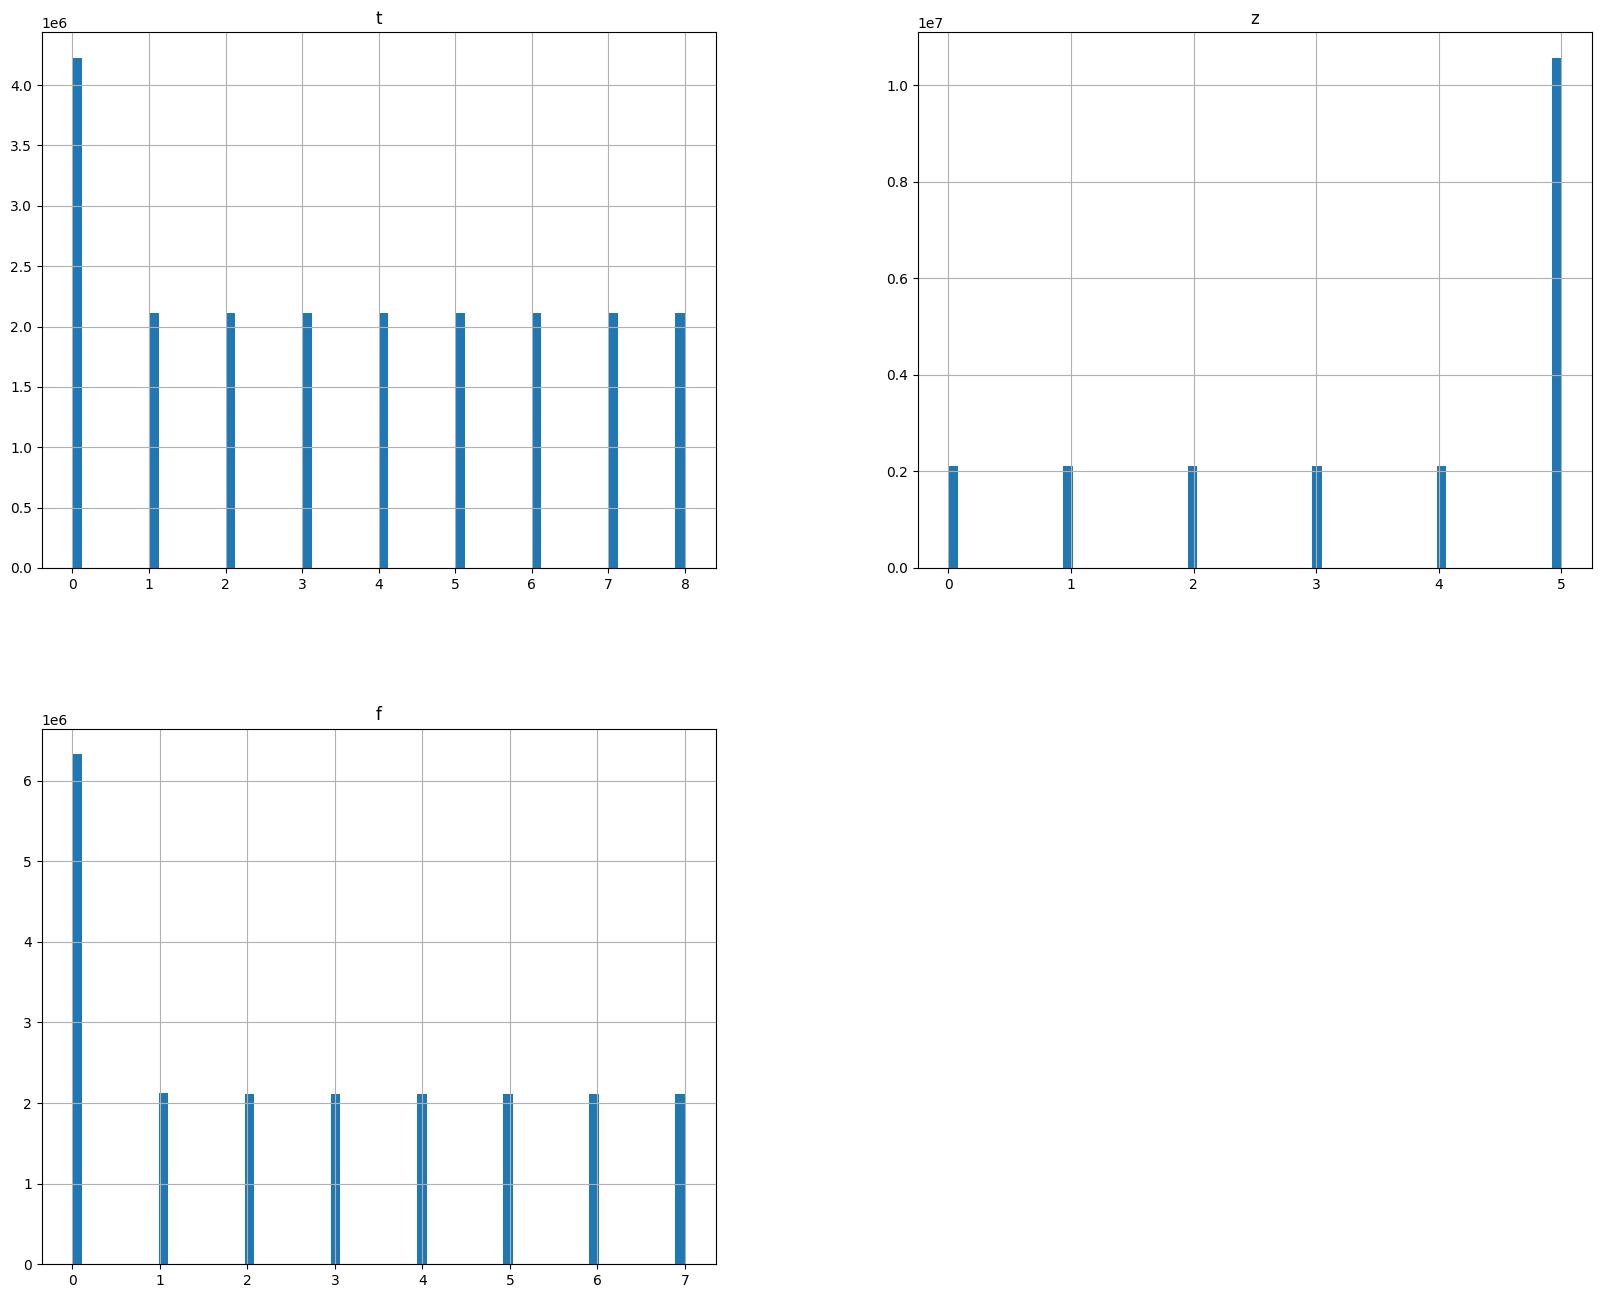

In [8]:
featureset_df.hist(figsize=(20,16), bins = 64)
plt.show()

In [9]:
X = pd.concat([featureset_df, df[['s', 'trial_id']]], axis=1)

In [10]:
Y = df.groupby(['trial_id', 'd', 'i', 'o'])['t'].shift(-1)

print(f"Label Statistics:")
print(f"Total rows: {len(Y)}")
print(f"Labeled rows: {Y.notna().sum()}")
print(f"Unlabeled rows (no future match): {Y.isna().sum()}")
print(f"Label coverage: {Y.notna().sum() / len(Y) * 100:.2f}%")

Label Statistics:
Total rows: 21136516
Labeled rows: 17331622
Unlabeled rows (no future match): 3804894
Label coverage: 82.00%


In [11]:
Y.fillna(1e15, inplace=True)

In [12]:
N_CLASSES = 5
Y_binned, Y_discritizer = train_and_transform_discretizer(Y.to_frame(), n_bins=N_CLASSES, strategy='quantile')

array([[<Axes: title={'center': 't'}>]], dtype=object)

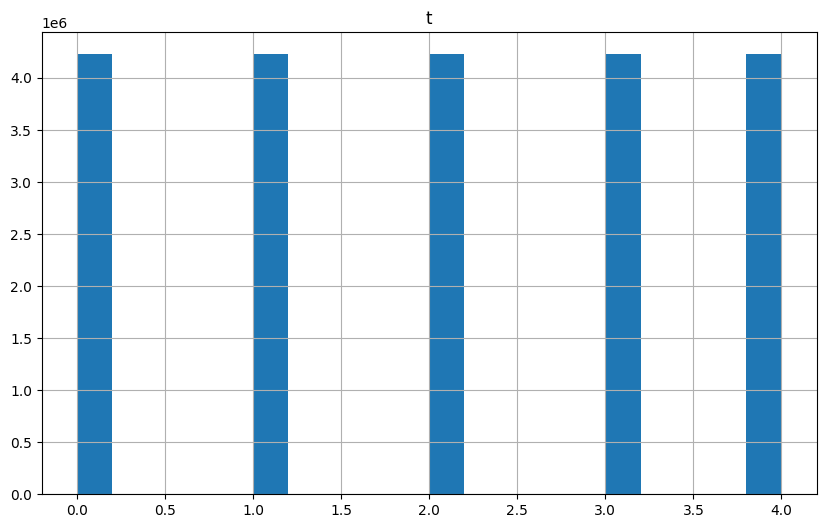

In [18]:
Y_binned.hist(figsize=(10,6), bins=20)

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binned, test_size=0.2, random_state=42, stratify=Y_binned
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_features = X_train_np.shape[1]

print(f"\nData Summary:")
print(f"  Features: {n_features}")
print(f"  Classes: {N_CLASSES}")
print(f"  Training samples: {len(X_train_np)}")
print(f"  Test samples: {len(X_test_np)}")


Data Summary:
  Features: 5
  Classes: 5
  Training samples: 16909212
  Test samples: 4227304


In [19]:
import numpy as np
import keras
from keras import layers
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sys
sys.path.append('..')
from learnedcache.activations import Squaremax, TaylorSoftmax

In [ ]:
from learnedcache.layers import FeatureOneHotEncoder
import keras.ops as ops

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Actual bins per feature: {n_bins_list}")

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized_features = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized_features)

combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(N_CLASSES)(combined)
output = Squaremax()(output)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_squaremax")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_np, Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
ax3.set_ylabel('True Class')
ax3.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()


Actual bins per feature: [9, 6, 8]


Model: "LearnedCache_squaremax"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_7 (Split)     │ [(None, 3),       │          0 │ input_layer_12[0… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 23)        │          0 │ split_7[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 25)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_7[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 5)         │        130 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squaremax_2         │ (None, 5)         │          0 │ dense_9[0][0]     │
│ (Squaremax)         │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130 (520.00 B)

 Trainable params: 130 (520.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


Actual bins per feature: [9, 6, 8]


Model: "LearnedCache_taylorsoftmax"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_5 (Split)     │ [(None, 3),       │          0 │ input_layer_10[0… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 23)        │          0 │ split_5[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 25)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_5[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        130 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ taylor_softmax_1    │ (None, 5)         │          0 │ dense_7[0][0]     │
│ (TaylorSoftmax)     │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130 (520.00 B)

 Trainable params: 130 (520.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 226s 426us/step - accuracy: 0.8554 - loss: 0.3973 - val_accuracy: 0.8543 - val_loss: 0.3791
Epoch 2/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 227s 429us/step - accuracy: 0.8562 - loss: 0.3848 - val_accuracy: 0.8562 - val_loss: 0.3787
Epoch 3/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 225s 425us/step - accuracy: 0.8562 - loss: 0.3845 - val_accuracy: 0.8580 - val_loss: 0.3882
Epoch 4/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 216s 407us/step - accuracy: 0.8561 - loss: 0.3852 - val_accuracy: 0.8581 - val_loss: 0.3782
Epoch 5/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 220s 416us/step - accuracy: 0.8560 - loss: 0.3838 - val_accuracy: 0.8548 - val_loss: 0.3830
Restoring model weights from the end of the best epoch: 4.

Test Accuracy: 0.8581
Trained for 5 epochs (early stopping)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86   2113652
           1       0.86      0.85      0.86   2113652

    acc

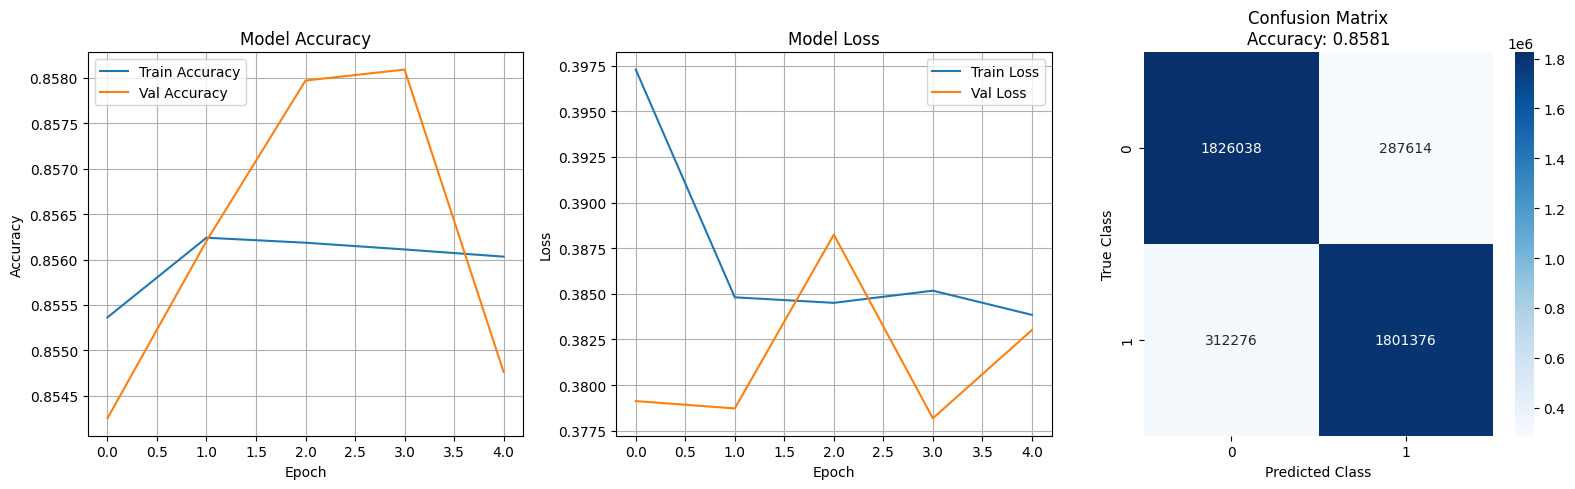

In [26]:
from learnedcache.layers import FeatureOneHotEncoder
import keras.ops as ops

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Actual bins per feature: {n_bins_list}")

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized_features = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized_features)

combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(N_CLASSES)(combined)
output = TaylorSoftmax()(output)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_taylorsoftmax")

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train_np,
    Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1,
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history["accuracy"], label="Train Accuracy")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history["loss"], label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()

In [27]:
Y_binary = (Y >= Y.quantile(0.5)).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print("n_bins_list:", n_bins_list)

from learnedcache.layers import FeatureOneHotEncoder
from keras import layers
from keras.callbacks import EarlyStopping
import keras

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized)
combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(1, activation="sigmoid")(combined)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_binary_slp")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", "AUC"])
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train_np,
    Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1,
)

y_prob = model.predict(X_test_np, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test accuracy:", accuracy_score(Y_test_np, y_pred))
print(classification_report(Y_test_np, y_pred))
cm = confusion_matrix(Y_test_np, y_pred)
print("Confusion matrix:\n", cm)

n_bins_list: [9, 6, 8]


Model: "LearnedCache_binary_slp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_6 (Split)     │ [(None, 3),       │          0 │ input_layer_11[0… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 23)        │          0 │ split_6[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 25)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_6[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         26 │ concatenate_8[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 222s 419us/step - AUC: 0.9026 - accuracy: 0.8633 - loss: 0.3718 - val_AUC: 0.9027 - val_accuracy: 0.8636 - val_loss: 0.3717
Epoch 2/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 221s 419us/step - AUC: 0.9026 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9026 - val_accuracy: 0.8634 - val_loss: 0.3719
Epoch 3/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 223s 421us/step - AUC: 0.9026 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9030 - val_accuracy: 0.8627 - val_loss: 0.3717
Epoch 4/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 220s 415us/step - AUC: 0.9027 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9029 - val_accuracy: 0.8634 - val_loss: 0.3720
Epoch 5/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 220s 415us/step - AUC: 0.9027 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9024 - val_accuracy: 0.8635 - val_loss: 0.3717
Restoring model weights from the end of the best epoch: 5.
Test accuracy: 0.8634519779036474
              precision    recall  f1-score   support

       